In [ ]:
# Objective

 # The objective of this notebook is to compare different time-series forecasting techniques on an hourly energy consumption dataset.

 # The workflow includes: Data preprocessing, Visualization of seasonal patterns, Train-test split ,Forecasting using four models , Model evaluation using MAE,Analysis using ACF and PACF plots

In [42]:
from google.colab import drive
drive.mount('/content/drive')       # The dataset is stored in Google Drive, so mount the drive to access it

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import os
os.listdir('/content/drive/MyDrive')

['education loan.pdf',
 'DSC_0097.JPG',
 'vanshika_certificates.pdf',
 'vanshika_agrawal_23scse1180119.docx',
 'Colab Notebooks',
 'vanshika_agrawal_23scse1180119_compressed.pdf',
 'Vanshika_Resume.pdf',
 'IMG20250714221913.jpg',
 'IMG_20250714_223311.jpg',
 'certificate.pdf',
 'Vanshika Resume.pdf',
 '144552104.zip',
 'pan card vanshika.pdf',
 'Vanshika Agrawal passbook.pdf',
 'archive.zip',
 'PlantDoc.zip',
 'Interview Rubrics (Job Fair).xlsx',
 'AI-Powered Plant Disease Detection & Recommendation System_compressed.pdf',
 'feedback vanshika .pdf',
 'Image-20251129T060925Z-1-001.zip',
 'Image',
 'resume (4).pdf',
 'rain_model.joblib',
 'Medical Image Classification (Brain Tumor Classification)report.pdf',
 'Medical_Image_Class.ipynb',
 'ImageBasedClassification.ipynb',
 'feedback form.pdf',
 'Mall_Customers.csv',
 'resume (1) (2).pdf',
 'vanshika resume (3).pdf',
 'vanshika resume (2).pdf',
 'vanshika resume (1).pdf',
 'vanshika resume.pdf',
 'vanshi resume.pdf',
 'nptel result (1).pd

In [44]:
import zipfile
#extract the zip file
zip_path = "/content/drive/MyDrive/forcastin dataset.zip"
extract_path = "/content/hourly_energy"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [46]:
import os
os.listdir(extract_path)

['est_hourly.paruqet',
 'PJMW_hourly.csv',
 'DOM_hourly.csv',
 'NI_hourly.csv',
 'PJM_Load_hourly.csv',
 'EKPC_hourly.csv',
 'FE_hourly.csv',
 'PJME_hourly.csv',
 'DAYTON_hourly.csv',
 'DUQ_hourly.csv',
 'COMED_hourly.csv',
 'pjm_hourly_est.csv',
 'AEP_hourly.csv',
 'DEOK_hourly.csv']

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [48]:
df = pd.read_csv("/content/hourly_energy/AEP_hourly.csv")

In [49]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.set_index("Datetime", inplace=True)
df.sort_index(inplace=True)
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


In [50]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121273 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121273 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB


,0
AEP_MW,0


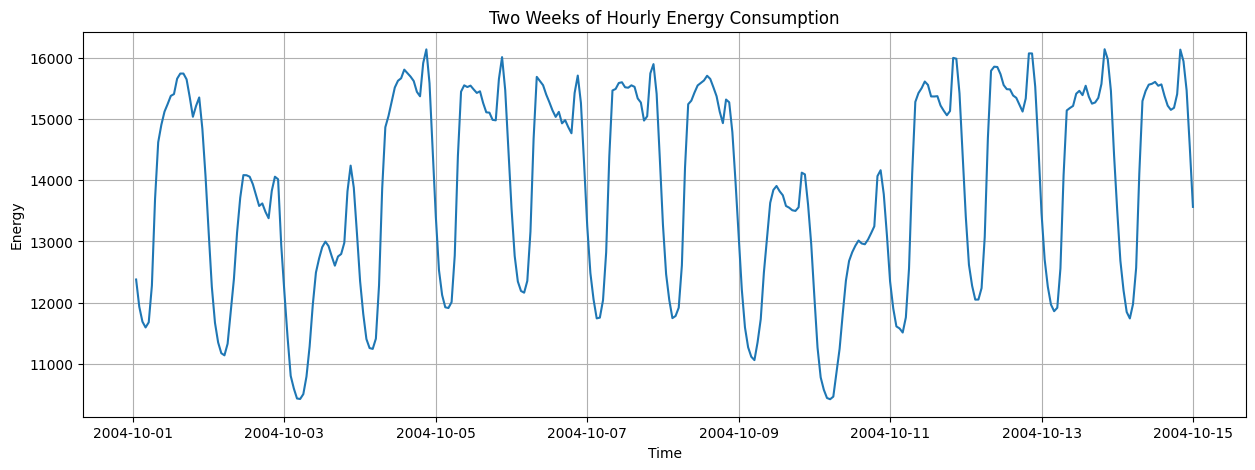

In [51]:
plt.figure(figsize=(15,5))
plt.plot(df.iloc[:24*14])
plt.title("Two Weeks of Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.grid(True)
plt.show()

In [52]:
train_data = df.iloc[:-24*7]
test_data = df.iloc[-24*7:]
print(train_data.shape)             # Train-Test Split  - The last seven days are reserved for testing while the remaining observations are used for training.
print(test_data.shape)

(121105, 1)
(168, 1)


In [54]:
naive_pred = test_data.shift(1)
naive_pred.iloc[0] = train_data.iloc[-1]         ## Naive Forecast-This method assumes that the next observation will be equal to the most recent observation.

In [55]:
season24 = df.shift(24)
season24_pred = season24.loc[test_data.index]  # Seasonal Naive (24) -Forecasts the current value using the observation from the same hour on the previous day.

In [56]:
season168 = df.shift(168)
season168_pred = season168.loc[test_data.index]  ### Seasonal Naive (168) -Forecasts the current value using the observation from the same hour in the previous week.

In [57]:
energy_data = df.tail(24 * 90)
target = energy_data.columns[0]

train_data = energy_data.iloc[:-24*7][target]
test_data = energy_data.iloc[-24*7:][target]

model = SARIMAX(
    train_data,
    order=(1,1,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit(disp=False)
sarima_pred = sarima_model.forecast(steps=len(test_data))      #SARIMA captures both trend and seasonal patterns in the data, making it suitable for hourly energy consumption forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [60]:
naive_pred = test_data.shift(1)
naive_pred.iloc[0] = train_data.iloc[-1]

season24_pred = energy_data[target].shift(24).loc[test_data.index]

season168_pred = energy_data[target].shift(168).loc[test_data.index]

mae_naive = mean_absolute_error(test_data, naive_pred)

mae_24 = mean_absolute_error(test_data, season24_pred)

mae_168 = mean_absolute_error(test_data, season168_pred)
mae_sarima = mean_absolute_error(test_data, sarima_pred)

In [61]:
leaderboard = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive (24)",
        "Seasonal Naive (168)",
        "SARIMA"
    ],
    "MAE": [
        mae_naive,
        mae_24,
        mae_168,
        mae_sarima
    ]
})

leaderboard = leaderboard.sort_values("MAE")

leaderboard

,Model,MAE
0,Naive,484.440476
2,Seasonal Naive (168),642.601190
1,Seasonal Naive (24),887.071429
3,SARIMA,1012.909700


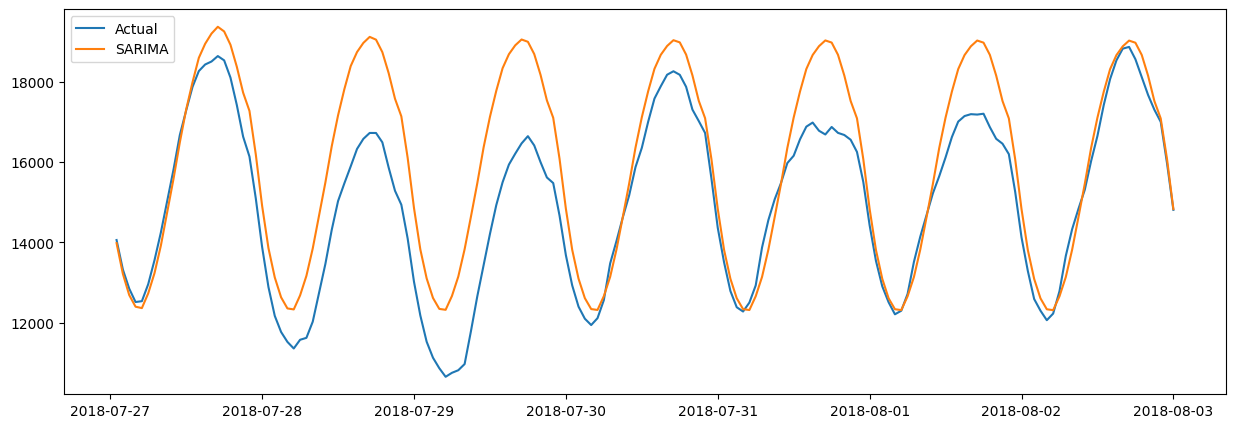

In [62]:
plt.figure(figsize=(15,5))
plt.plot(test_data,label="Actual")
plt.plot(sarima_pred,label="SARIMA")
plt.legend()
plt.show()

<Figure size 1200x400 with 0 Axes>

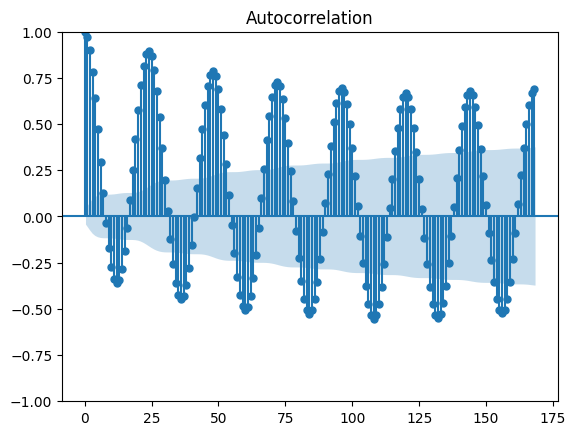

In [63]:
plt.figure(figsize=(12,4))

plot_acf(train_data, lags=168)
plt.show()

<Figure size 1200x400 with 0 Axes>

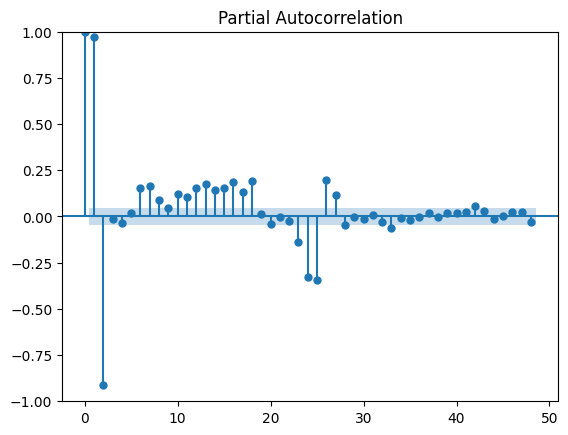

In [64]:
plt.figure(figsize=(12,4))

plot_pacf(train_data, lags=48)
plt.show()

In [65]:
# Observations:
# Lag 24:Strong spike indicates daily seasonality.
# Lag 168:Strong spike indicates weekly seasonality.

In [ ]:
# Conclusion

# This notebook compared four forecasting methods: Naive, Seasonal Naive (24), Seasonal Naive (168), SARIMA
 # Among the baseline models, Seasonal Naive (t−168) performed strongly because the dataset follows a weekly repeating pattern.

# The ACF and PACF plots also confirmed the presence of daily and weekly seasonality, making SARIMA an appropriate statistical model for this dataset.